# Car Price Prediction with Machine Learning

### CodeAlpha Data Science Internship — Task 3

## Project Overview

This project focuses on predicting the selling price of used cars using
Machine Learning regression techniques.

The project uses car-related features such as car age, present price,
kilometers driven, fuel type, selling type, transmission, and number of
previous owners to build a model for predicting car prices.

Python is used for data preprocessing, exploratory data analysis,
feature engineering, machine learning model development,
visualization, and model evaluation.

The project also compares different regression models to identify the
model that provides better performance for car price prediction.

## Objective

The main objectives of this project are:

1. Load and understand the car price dataset.
2. Clean and preprocess the dataset.
3. Perform exploratory data analysis.
4. Analyze the factors affecting car selling prices.
5. Perform feature engineering such as calculating car age.
6. Convert categorical features into numerical form.
7. Split the dataset into training and testing sets.
8. Train regression models for car price prediction.
9. Evaluate model performance using MAE, RMSE, and R² score.
10. Compare different regression models and select the best-performing model.
11. Visualize actual versus predicted car prices.
12. Analyze feature importance to understand influential factors.
13. Predict the selling price of a new car using the trained model.
14. Understand the real-world application of Machine Learning in vehicle price prediction.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab
- Jupyter Notebook
- GitHub

## Dataset

The dataset used for this project is a used car price dataset containing
information about different cars and their selling prices.

The dataset contains features related to the car's price, age, usage,
fuel type, transmission, selling type, and previous ownership.

### Dataset Features

| Feature | Description |
|---|---|
| Car_Name | Name or model of the car |
| Year | Manufacturing year of the car |
| Selling_Price | Selling price of the car in lakhs |
| Present_Price | Current/ex-showroom price of the car in lakhs |
| Driven_kms | Total kilometers driven by the car |
| Fuel_Type | Type of fuel used by the car |
| Selling_type | Type of seller, such as Dealer or Individual |
| Transmission | Type of transmission, Manual or Automatic |
| Owner | Number of previous owners |

The target variable for this project is:

**Selling_Price**

The remaining relevant features are used as input variables to train
the machine learning regression models.

### Dataset Source

The dataset was obtained from Kaggle and is commonly known as the
Car Price Prediction / Used Cars dataset.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-price-predictionused-cars' dataset.
Path to dataset files: /kaggle/input/car-price-predictionused-cars


In [3]:
import pandas as pd
import os
df = pd.read_csv(os.path.join(path, 'car data.csv'))
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load and Inspect Dataset

In [6]:
import os
df = pd.read_csv(os.path.join(path, 'car data.csv'))

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [11]:
df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (299, 9)


Exploratory Data Analysis

Selling Price Distribution

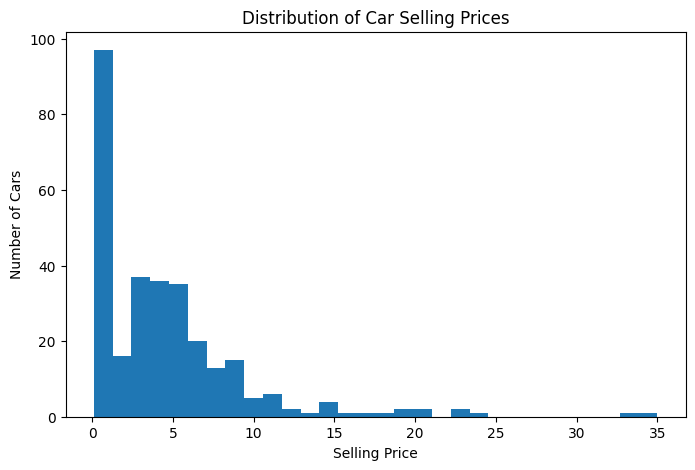

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['Selling_Price'], bins=30)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

Selling Price vs Present Price

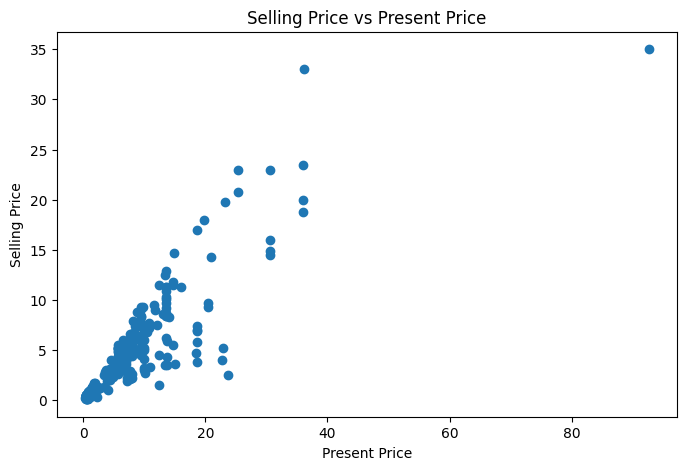

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(df['Present_Price'], df['Selling_Price'])

plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

Selling Price vs Kilometers Driven

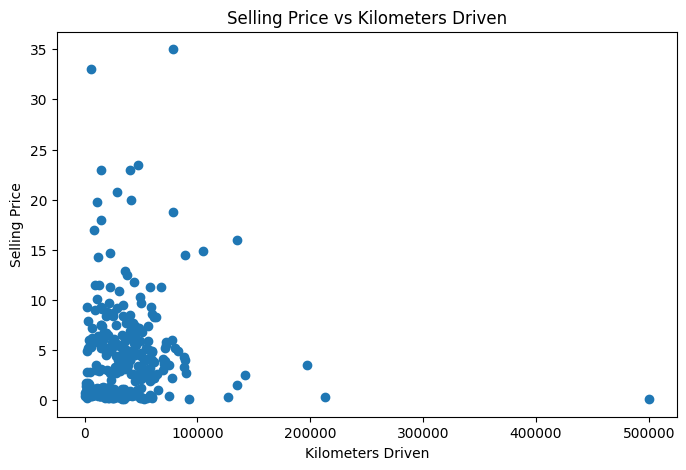

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(df['Driven_kms'], df['Selling_Price'])

plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')

plt.show()

Feature Engineering

In [15]:
current_year = 2026

df['Car_Age'] = current_year - df['Year']

df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


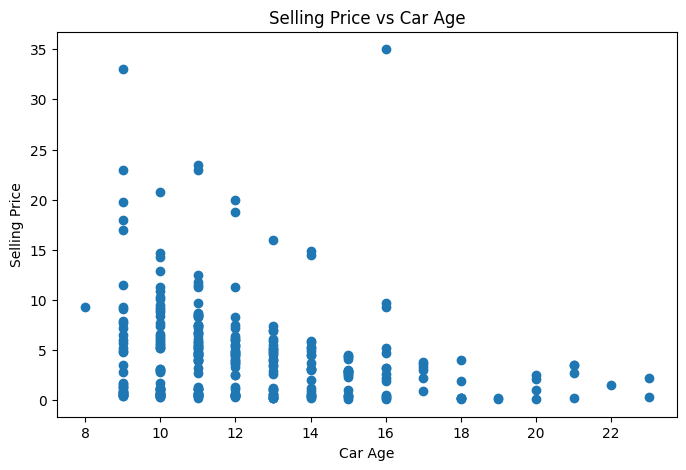

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df['Car_Age'], df['Selling_Price'])

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')

plt.show()

Prepare Features and Target

In [17]:
X = df.drop(['Selling_Price', 'Car_Name', 'Year'], axis=1)

y = df['Selling_Price']

In [18]:
X.head()

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,5.59,27000,Petrol,Dealer,Manual,0,12
1,9.54,43000,Diesel,Dealer,Manual,0,13
2,9.85,6900,Petrol,Dealer,Manual,0,9
3,4.15,5200,Petrol,Dealer,Manual,0,15
4,6.87,42450,Diesel,Dealer,Manual,0,12


Encode Categorical Features

In [19]:
X = pd.get_dummies(
    X,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

In [20]:
X.head()

,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,12,False,True,False,True
1,9.54,43000,0,13,True,False,False,True
2,9.85,6900,0,9,False,True,False,True
3,4.15,5200,0,15,False,True,False,True
4,6.87,42450,0,12,True,False,False,True


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Present_Price            299 non-null    float64
 1   Driven_kms               299 non-null    int64  
 2   Owner                    299 non-null    int64  
 3   Car_Age                  299 non-null    int64  
 4   Fuel_Type_Diesel         299 non-null    bool   
 5   Fuel_Type_Petrol         299 non-null    bool   
 6   Selling_type_Individual  299 non-null    bool   
 7   Transmission_Manual      299 non-null    bool   
dtypes: bool(4), float64(1), int64(3)
memory usage: 12.8 KB


Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


Train Linear Regression Model

In [23]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [24]:
linear_predictions = linear_model.predict(X_test)

In [25]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
-------------------------
MAE : 1.472545750817864
RMSE: 2.5245049230018752
R²  : 0.7527233824220487


Train Random Forest

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [27]:
rf_predictions = rf_model.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regression")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regression
-------------------------
MAE : 1.4787925
RMSE: 3.534568152494023
R²  : 0.5152661732571383


Compare the Models

In [29]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse
    ],
    'R2 Score': [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472546,2.524505,0.752723
1,Random Forest,1.478792,3.534568,0.515266


Select the Best Model

In [30]:
if rf_r2 > linear_r2:
    best_model = rf_model
    best_predictions = rf_predictions
    best_model_name = "Random Forest Regressor"
else:
    best_model = linear_model
    best_predictions = linear_predictions
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Linear Regression


Actual vs Predicted Price

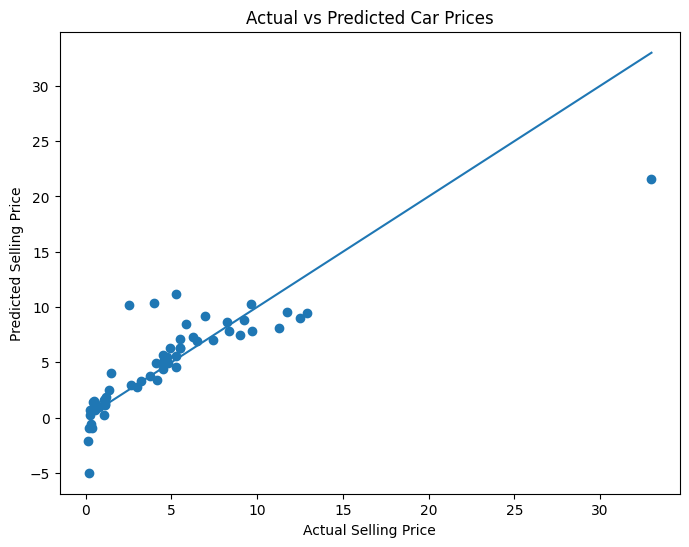

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, best_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')

plt.show()

Feature Importance

In [32]:
if best_model_name == "Random Forest Regressor":

    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by='Importance',
        ascending=False
    )

    print(feature_importance)

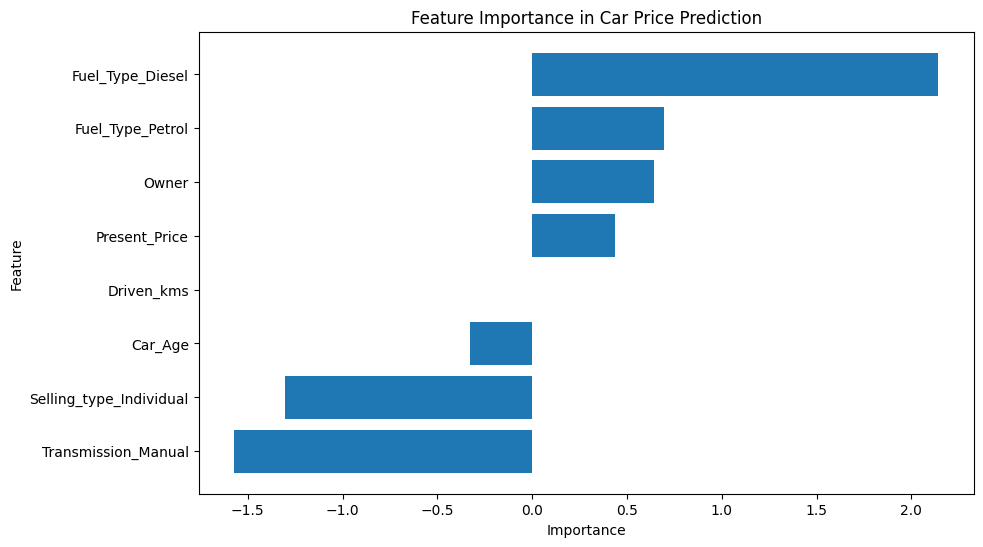

In [34]:
plt.figure(figsize=(10,6))

# Define feature_importance if it was not defined in the previous cell
if 'feature_importance' not in locals():
    if best_model_name == "Random Forest Regressor":
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': rf_model.feature_importances_
        })
    elif best_model_name == "Linear Regression":
        # For Linear Regression, coefficients represent feature importance
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': linear_model.coef_
        })
    feature_importance = feature_importance.sort_values(
        by='Importance',
        ascending=False
    )

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance in Car Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Predict a New Car Price

In [35]:
new_car = pd.DataFrame({
    'Present_Price': [5.5],
    'Driven_kms': [30000],
    'Owner': [0],
    'Car_Age': [4],
    'Fuel_Type_Diesel': [0],
    'Fuel_Type_Petrol': [1],
    'Selling_type_Individual': [0],
    'Transmission_Manual': [1]
})

In [36]:
new_car = new_car.reindex(
    columns=X.columns,
    fill_value=0
)

In [37]:
predicted_price = best_model.predict(new_car)

print(
    f"Predicted Car Selling Price: ₹{predicted_price[0]:.2f} Lakhs"
)

Predicted Car Selling Price: ₹6.51 Lakhs


## Conclusion

This project developed a machine learning regression system for
predicting used car selling prices.

The workflow included:

- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering
- Categorical feature encoding
- Train-test splitting
- Linear Regression
- Random Forest Regression
- Model evaluation using MAE, RMSE and R²
- Actual vs Predicted visualization
- Feature importance analysis
- New car price prediction

The comparison of regression models helped identify the model
that performed best on the test dataset.

This project demonstrates how machine learning can be applied
to real-world automotive pricing problems such as used-car
valuation, resale price estimation and pricing assistance.